<a href="https://colab.research.google.com/github/Ayu-sshhhhh/IPL-Cricket-Data-Analysis/blob/main/IPL_Cricket_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing necessary tools

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset

In [21]:
matches = pd.read_csv('/content/matches.csv')
deliveries = pd.read_csv('/content/deliveries.csv')

# Getting a glimpse of the data

In [32]:
print("Matches Info:")
print(matches.info())
matches.head()


Matches Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               636 non-null    int64         
 1   season           636 non-null    int64         
 2   city             636 non-null    object        
 3   date             636 non-null    datetime64[ns]
 4   team1            636 non-null    object        
 5   team2            636 non-null    object        
 6   toss_winner      636 non-null    object        
 7   toss_decision    636 non-null    object        
 8   result           636 non-null    object        
 9   dl_applied       636 non-null    int64         
 10  winner           636 non-null    object        
 11  win_by_runs      636 non-null    int64         
 12  win_by_wickets   636 non-null    int64         
 13  player_of_match  636 non-null    object        
 14  venue            636 non-nul

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN


In [33]:
print("\nDeliveries Info:")
print(deliveries.info())
deliveries.head()


Deliveries Info:
<class 'pandas.core.frame.DataFrame'>
Index: 150459 entries, 0 to 150459
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          150459 non-null  int64 
 1   inning            150459 non-null  int64 
 2   batting_team      150459 non-null  object
 3   bowling_team      150459 non-null  object
 4   over              150459 non-null  int64 
 5   ball              150459 non-null  int64 
 6   batsman           150459 non-null  object
 7   non_striker       150459 non-null  object
 8   bowler            150459 non-null  object
 9   is_super_over     150459 non-null  int64 
 10  wide_runs         150459 non-null  int64 
 11  bye_runs          150459 non-null  int64 
 12  legbye_runs       150459 non-null  int64 
 13  noball_runs       150459 non-null  int64 
 14  penalty_runs      150459 non-null  int64 
 15  batsman_runs      150459 non-null  int64 
 16  extra_runs        150459 

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


# Data Cleaning

### Checking for null values

In [24]:
df = matches.merge(deliveries, left_on='id', right_on='match_id')
df.isna().sum()

,0
id,0
season,0
city,1700
date,0
team1,0
team2,0
toss_winner,0
toss_decision,0
result,0
dl_applied,0


### Tackling null values

In [25]:
matches.replace('Rising Pune Supergiants', 'Rising Pune Supergiant', inplace=True)
deliveries.replace('Rising Pune Supergiants', 'Rising Pune Supergiant', inplace=True)

matches['city'] = matches['city'].fillna('Dubai')

# Handle 'No Result' matches
matches['winner'] = matches['winner'].fillna('No Result')
matches['player_of_match'] = matches['player_of_match'].fillna('None')

# Drop the empty 'umpire3' column
matches.drop(columns=['umpire3'], inplace=True)

# Convert date column to datetime format
matches['date'] = pd.to_datetime(matches['date'])

# Remove duplicate rows in deliveries
deliveries.drop_duplicates(inplace=True)

# Save cleaned data (optional)
matches.to_csv('cleaned_matches.csv', index=False)
deliveries.to_csv('cleaned_deliveries.csv', index=False)

print("Data cleaning complete. Datasets are ready for analysis!")

Data cleaning complete. Datasets are ready for analysis!


# Setting style for plots

In [26]:
sns.set_theme(style="whitegrid")

## Most Successful IPL Teams (Wins)

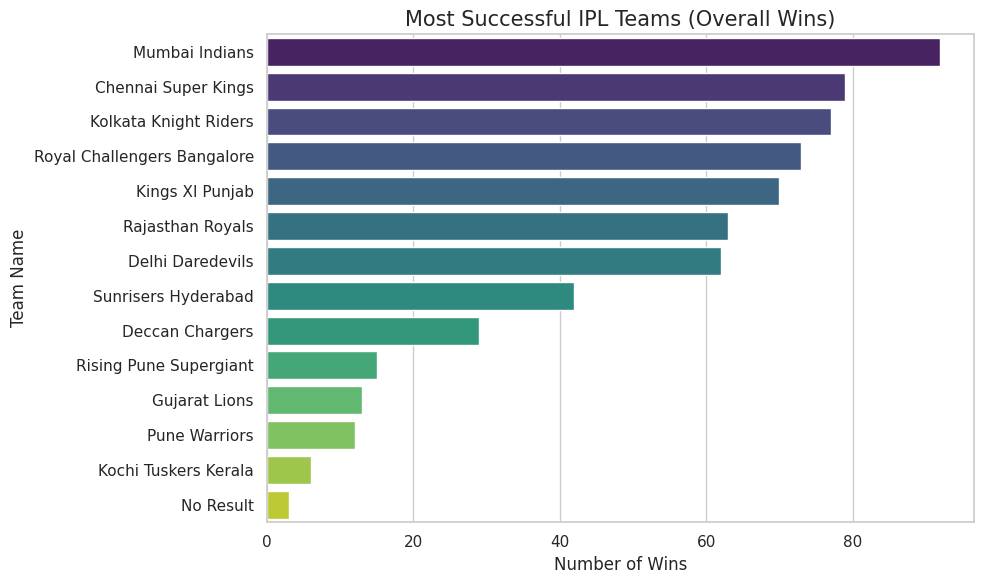

In [27]:
plt.figure(figsize=(10, 6))
top_teams = matches['winner'].value_counts()
sns.barplot(x=top_teams.values, y=top_teams.index, palette='viridis', hue=top_teams.index, legend=False)
plt.title('Most Successful IPL Teams (Overall Wins)', fontsize=15)
plt.xlabel('Number of Wins', fontsize=12)
plt.ylabel('Team Name', fontsize=12)
plt.tight_layout()
plt.savefig('most_successful_teams.png')
plt.show()
plt.close()

## Number of Matches Played per Season

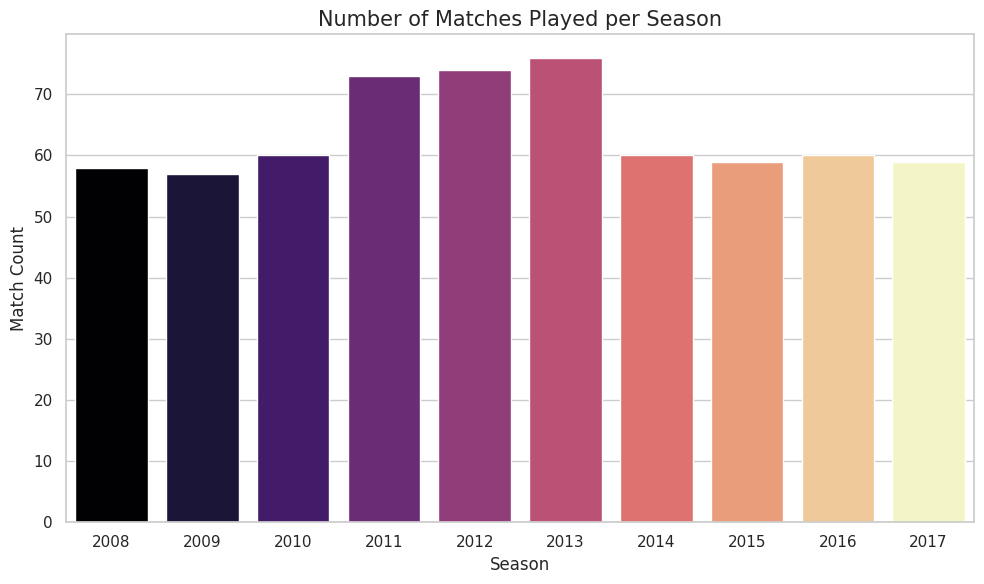

In [28]:
plt.figure(figsize=(10, 6))
sns.countplot(x='season', data=matches, palette='magma', hue='season', legend=False)
plt.title('Number of Matches Played per Season', fontsize=15)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Match Count', fontsize=12)
plt.tight_layout()
plt.savefig('matches_per_season.png')
plt.show()
plt.close()

## Toss Decision Preference

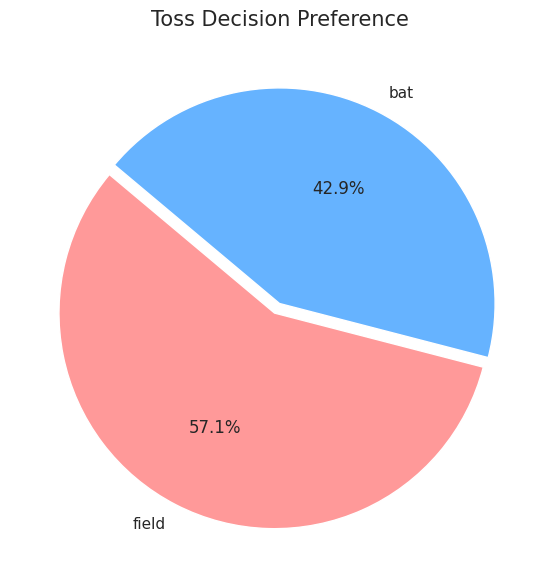

In [29]:
plt.figure(figsize=(7, 7))
toss_decision = matches['toss_decision'].value_counts()
plt.pie(toss_decision, labels=toss_decision.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'], explode=(0.05, 0))
plt.title('Toss Decision Preference', fontsize=15)
plt.savefig('toss_decision.png')
plt.show()
plt.close()

## Top 10 Run scorers (batsmen)

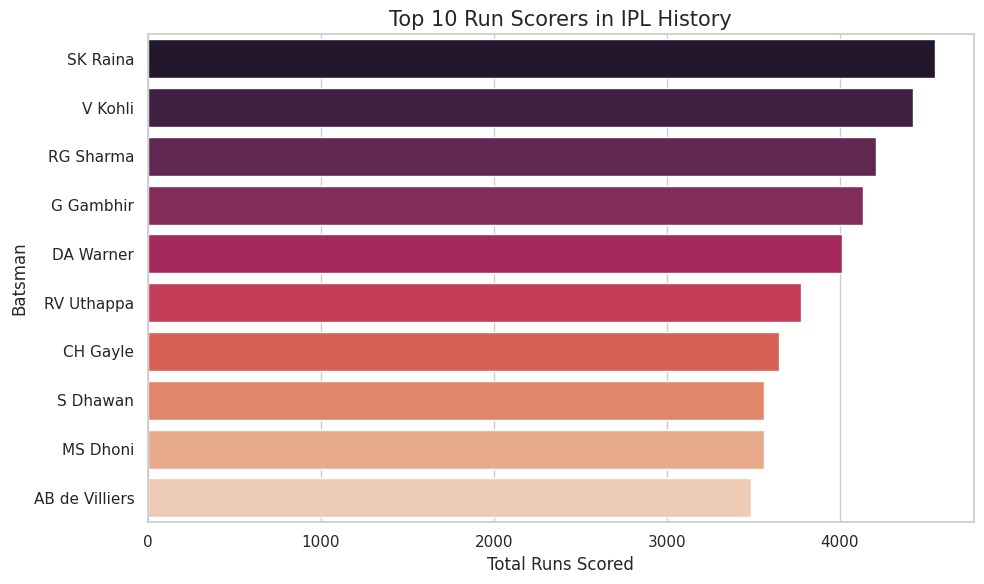

In [30]:
top_batsmen = deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette='rocket', hue=top_batsmen.index, legend=False)
plt.title('Top 10 Run Scorers in IPL History', fontsize=15)
plt.xlabel('Total Runs Scored', fontsize=12)
plt.ylabel('Batsman', fontsize=12)
plt.tight_layout()
plt.savefig('top_run_scorers.png')
plt.show()
plt.close()

## Top 5 Wicket Takers (Bowlers)

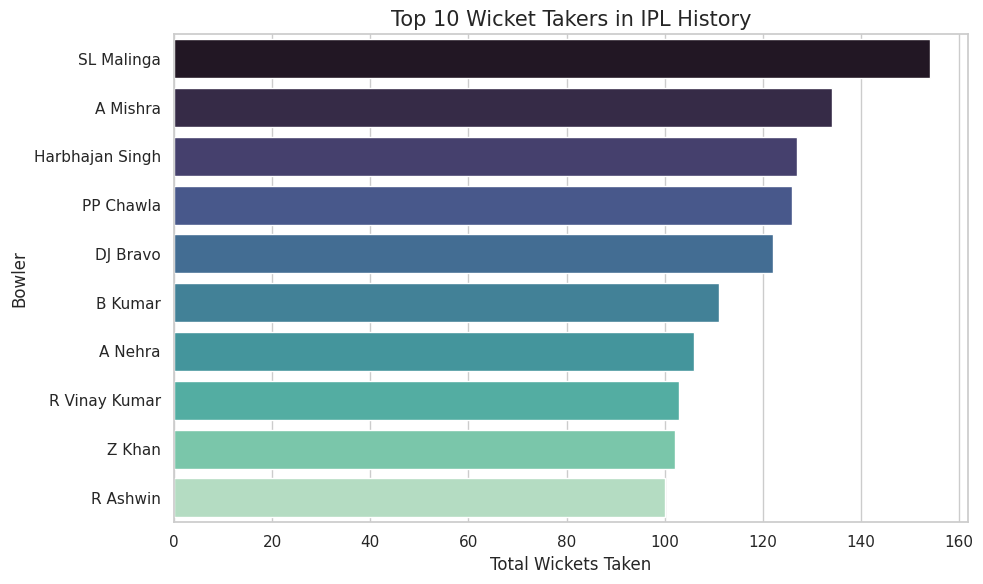

In [31]:
bowler_wickets = deliveries.dropna(subset=['player_dismissed'])
bowler_wickets = bowler_wickets[~bowler_wickets['dismissal_kind'].isin(['run out', 'retired hurt', 'obstructing the field'])]
top_bowlers = bowler_wickets.groupby('bowler')['player_dismissed'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette='mako', hue=top_bowlers.index, legend=False)
plt.title('Top 10 Wicket Takers in IPL History', fontsize=15)
plt.xlabel('Total Wickets Taken', fontsize=12)
plt.ylabel('Bowler', fontsize=12)
plt.tight_layout()
plt.savefig('top_wicket_takers.png')
plt.show()
plt.close()